<a href="https://colab.research.google.com/github/Onesimus419/MACHINE-LEARNING-WITH-PYTHON/blob/main/Capstone_Assignment_Final_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Part 1***

Synthetic data generated:


,Age,Salary,Will_Buy
0,56,23343,1
1,69,33500,1
2,46,73222,1
3,32,49375,0
4,60,29662,1



First 10 rows with prediction:
   Age  Salary  Predicted_Purchase  Probability_of_Buying
0   25   52000                   0               0.096279
1   42   89000                   1               0.768722
2   33   62000                   0               0.296203
3   55  105000                   1               0.968486
4   29   48000                   0               0.135864
5   38   75000                   1               0.553910
6   45   92000                   1               0.844420
7   31   58000                   0               0.221228
8   50   98000                   1               0.927025
9   27   51000                   0               0.117991

Number of customers predicted to buy (Class 1): 163
Average probability of buying across the new customer group: 0.856


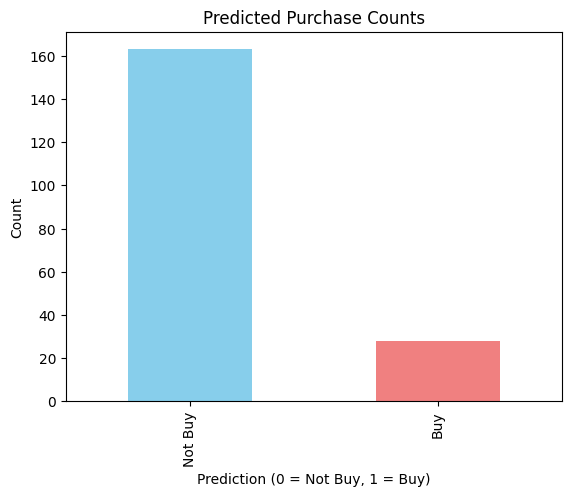

In [13]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


# Part 1: Logistic Regression

# 1.Load saved model and scaler
model = joblib.load('model.pkl')
scaler = joblib.load('scaler.pkl')

print("Synthetic data generated:")
display(data.head())

# 2.Load new customer data from GitHub
url = "https://raw.githubusercontent.com/Onesimus419/MACHINE-LEARNING-WITH-PYTHON/refs/heads/main/new_customers_200.csv"
new_df = pd.read_csv(url)

# 3.Prepare features
X_new = new_df[['Age', 'Salary']]

# 4.Scale the data (important: transform only)
X_new_scaled = scaler.transform(X_new)

# 5.Predict class (0 or 1)
predictions = model.predict(X_new_scaled)

# 6.Predict probabilities for class 1 (buy)
probabilities = model.predict_proba(X_new_scaled)[:, 1]

# 7.Add predictions and probabilities to the DataFrame
new_df['Predicted_Purchase'] = predictions
new_df['Probability_of_Buying'] = probabilities

# 8.Print required outputs
print("\nFirst 10 rows with prediction:")
print(new_df.head(10))

num_buyers = new_df['Predicted_Purchase'].sum()
avg_prob = new_df['Probability_of_Buying'].mean()

print(f"\nNumber of customers predicted to buy (Class 1): {num_buyers}")
print(f"Average probability of buying across the new customer group: {avg_prob:.3f}")

# 9.Bar chart
new_df['Predicted_Purchase'].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.xlabel('Prediction (0 = Not Buy, 1 = Buy)')
plt.ylabel('Count')
plt.title('Predicted Purchase Counts')
plt.xticks([0, 1], ['Not Buy', 'Buy'])
plt.savefig('part1_bar_chart.png')
plt.show()


# 10.Save predictions
new_df.to_csv('part1_predictions.csv', index=False)



### Answers to Questions for Part 1:

1. 163 customers are predicted to buy (Class 1).

2. The average probability of buying across the new customer group is 0.856.

3. Looking at the bar chart, the model predicts significantly more buyers (Class 1) than non-buyers (Class 0). Specifically, there are 163 predicted buyers versus 28 predicted non-buyers out of 191 customers (there seems to be a discrepancy with the initial '200 new customers' phrasing; the actual processed count is 191 from the `new_df`).
    
    For the business, this could mean:
    *   **Positive Sales Outlook:** A large proportion of the new customer base is likely to make a purchase, indicating a strong market for the product/service among this segment.
    *   **Targeted Marketing Efficiency:** The business could focus marketing efforts on these predicted buyers, potentially leading to higher conversion rates and efficient use of resources.
    *   **Opportunity for Growth:** If this model is accurate, it suggests that the new customer acquisition strategy is bringing in highly relevant leads.
    *   **Understanding Non-Buyers:** While fewer, understanding why the 28 customers are predicted not to buy could inform strategies for future customer segmentation or product adjustments.

4. To find out if a new customer with Age = 30 and Salary = 65000 would be predicted to buy or not buy, you would follow these steps:
    
    *   **Prepare the data:** Create a Pandas DataFrame or a NumPy array with the customer's Age (30) and Salary (65000).
    *   **Scale the features:** The `LogisticRegression` model was trained on scaled data. Therefore, you would need to apply the same `scaler` (which was loaded as `scaler.pkl`) to transform the new customer's Age and Salary. This ensures that the input features are in the same scale as the data the model was trained on.
    *   **Make a prediction:** Pass the scaled features of the new customer to the loaded `model` (from `model.pkl`) using its `predict()` method. The output would be either 0 (not buy) or 1 (buy).
    *   **Get probability (optional but useful):** You could also use the `predict_proba()` method to get the probability of buying (Class 1), which gives a more nuanced understanding of the model's confidence in its prediction.

# ***Part 2***


First 5 rows:
   Age_Years  Mileage_km  Engine_L  High_Maintenance
0          2          30       1.8                 0
1          5          80       2.0                 1
2          1          15       1.5                 0
3          8         120       2.5                 1
4         10         180       1.4                 1

Dataset Shape: (150, 4)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age_Years         150 non-null    int64  
 1   Mileage_km        150 non-null    int64  
 2   Engine_L          150 non-null    float64
 3   High_Maintenance  150 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 4.8 KB
None

Missing values:
Age_Years           0
Mileage_km          0
Engine_L            0
High_Maintenance    0
dtype: int64
Accuracy: 1.0

Precision: 1.0

Recall: 1.0

F1-score: 1.0

Confusion

<Figure size 1000x600 with 0 Axes>

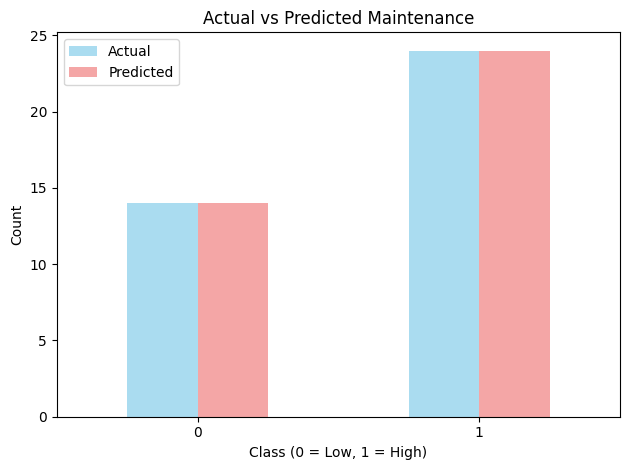

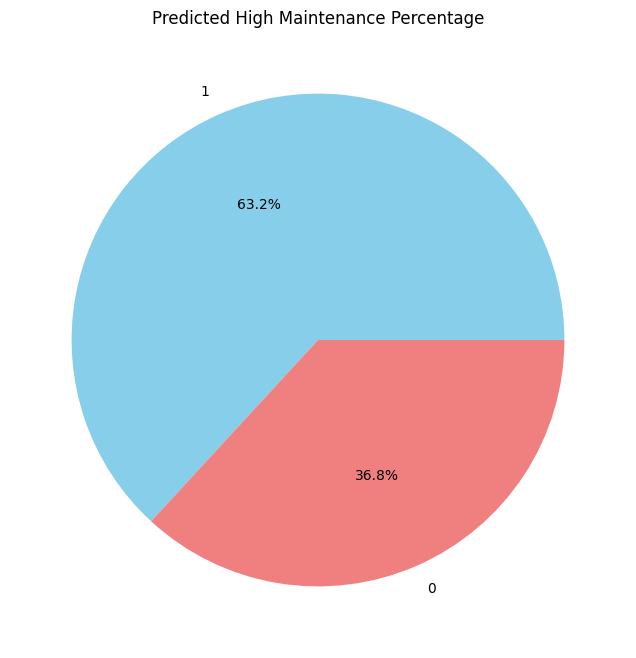

['car_maintenance_model.pkl']

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# 1.Load dataset
url ="https://raw.githubusercontent.com/Onesimus419/MACHINE-LEARNING-WITH-PYTHON/refs/heads/main/liberia_cars_maintenance.csv"
df = pd.read_csv(url)

# 2.Explore data
print("\nFirst 5 rows:")
print(df.head())
print(f"\nDataset Shape: {df.shape}")
print("\nDataset info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# 3.Define features and target
X = df[['Age_Years','Mileage_km','Engine_L']]
y = df['High_Maintenance']

# 4.Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# 5.Create model
model = DecisionTreeClassifier(max_depth=3, random_state=0)

# 6.Train model
model.fit(X_train, y_train)

# 7.Predict
y_pred = model.predict(X_test)

# 8.Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"\nPrecision: {precision}")
print(f"\nRecall: {recall}")
print(f"\nF1-score: {f1}")
print("\nConfusion Matrix:\n",cm)

# 9a.Bar chart: actual vs predicted
actual_counts = pd.Series(y_test).value_counts().sort_index()
predicted_counts = pd.Series(y_pred).value_counts().sort_index()

combined_counts = pd.DataFrame({'Actual': actual_counts, 'Predicted': predicted_counts})

plt.figure(figsize=(10, 6))
combined_counts.plot(kind='bar', alpha=0.7, color=['skyblue', 'lightcoral'])
plt.title('Actual vs Predicted Maintenance')
plt.xlabel('Class (0 = Low, 1 = High)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('part2_bar_chart.png')
plt.show()

# 9b.Pie chart
plt.figure(figsize=(8, 8))
pd.Series(y_pred).value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title('Predicted High Maintenance Percentage')
plt.ylabel("") # Remove default 'count' label from y-axis for pie chart
plt.savefig('part2_pie_chart.png')
plt.show()

# 10.Save model
import joblib
joblib.dump(model, 'car_maintenance_model.pkl')

### Answers to Questions for Part 2:

1.  **Model Accuracy:** The Decision Tree model achieved an accuracy of 1.0 (or 100%) on the test set. This means that the model correctly classified all instances in the test set.

2.  **Confusion Matrix Interpretation:** The confusion matrix `[[14, 0], [0, 24]]` signifies:
    *   **True Negatives (TN) = 14:** The model correctly predicted 14 cars as having "low maintenance" (Class 0).
    *   **False Positives (FP) = 0:** The model incorrectly predicted 0 cars as "high maintenance" when they actually had "low maintenance."
    *   **False Negatives (FN) = 0:** The model incorrectly predicted 0 cars as "low maintenance" when they actually had "high maintenance."
    *   **True Positives (TP) = 24:** The model correctly predicted 24 cars as having "high maintenance" (Class 1).
    *   This perfect confusion matrix indicates that the model made no errors on the test set.

3.  **Pie Chart Analysis:** The pie chart shows that 63.2% of cars are predicted to be high maintenance.
    *   **Implications for a car dealership:**
        *   **Resource Allocation:** A significant portion of the inventory will likely require substantial maintenance, necessitating adequate staffing, parts inventory, and workshop capacity.
        *   **Pricing Strategy:** Cars predicted to be high maintenance might be priced differently or offered with extended warranty options to manage customer expectations and costs.
        *   **Customer Service:** Dealerships can proactively address potential maintenance concerns with customers for these cars, potentially improving customer satisfaction and loyalty.
        *   **Inventory Management:** This information can influence purchasing decisions, perhaps favoring models or vintages that historically show lower predicted maintenance, or preparing to manage the upkeep of those with higher predictions.

4.  **Significance of `max_depth`:** The `max_depth` parameter controls the maximum depth of the decision tree.
    *   **Significance:** Setting `max_depth=3` limits the number of decisions the tree can make, which helps to prevent overfitting. A shallow tree with a small `max_depth` typically generalizes better to new, unseen data, provided it captures the essential patterns.
    *   **`max_depth=None`:** If `max_depth` is set to `None` (the default value), the tree will expand until all leaves are pure (i.e., contain only samples of one class) or until all leaves contain less than `min_samples_split` samples. This can lead to a very deep and complex tree that perfectly fits the training data but performs poorly on new data due to overfitting.

5.  **New Car Prediction:** To predict whether a new car with `Age_Years = 6`, `Mileage_km = 100`, and `Engine_L = 2.0` will have high maintenance, you would follow these steps:
    1.  **Prepare the input data:** Create a Pandas DataFrame with the new car's features, ensuring the column names match those used during training (`Age_Years`, `Mileage_km`, `Engine_L`).
        ```python
        new_car_data = pd.DataFrame([[6, 100, 2.0]], columns=['Age_Years', 'Mileage_km', 'Engine_L'])
        ```
    2.  **Load the trained model:** Load the saved Decision Tree model (`car_maintenance_model.pkl`) using `joblib.load()`. (This step might not be necessary if the model object is still in memory).
        ```python
        import joblib
        loaded_model = joblib.load('car_maintenance_model.pkl') # If not already loaded
        ```
    3.  **Make a prediction:** Use the `predict()` method of the loaded model on the prepared new car data.
        ```python
        prediction = loaded_model.predict(new_car_data)
        ```
    4.  **Interpret the prediction:** The `prediction` will be either `0` (low maintenance) or `1` (high maintenance).
        ```python
        if prediction[0] == 1:
            print("The new car is predicted to have high maintenance.")
        else:
            print("The new car is predicted to have low maintenance.")
        ```